# # Period 2 — Visualization & Communication

## Focus: visualize and explain the Urban Heat Island (UHI) effect in the chosen area.


In [1]:
from pathlib import Path
import io, os, re, gc, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rasterio
from rasterio.mask import mask
from rasterio.transform import from_bounds
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath


In [2]:
os.environ.setdefault("GDAL_DISABLE_READDIR_ON_OPEN", "EMPTY_DIR")
os.environ.setdefault("PROJ_NETWORK", "OFF")
warnings.filterwarnings("ignore", message=".*PROJ:.*network.*")

ISO3 = "NLD"
CITY = "Utrecht"
ERA5_YEARS = list(range(2020, 2026))
RING_KM = 25
S2_TO_MONTH_TOLERANCE_DAYS = 46

PROJECT_ROOT = Path.cwd()
DATA = PROJECT_ROOT / "Data"
GADM = DATA / "gadm_410.gpkg"
if not GADM.exists():
    alt = DATA / "gadm_410_europe.gpkg"
    if alt.exists():
        GADM = alt
ERA5_DAILY = DATA / "derived-era5-land-daily-statistics"
S2_NDVI = DATA / "sentinel2_ndvi"
ECA_TX = DATA / "ECA_blend_tx"
OUT = PROJECT_ROOT / "outputs"
OUT.mkdir(exist_ok=True)

In [3]:
def dms_to_dd(dms: str) -> float:
    s = str(dms).strip()
    sign = -1 if s.startswith("-") else 1
    d, m, sec = [float(x) for x in s.replace("+","").replace("-","").split(":")]
    return sign * (d + m/60.0 + sec/3600.0)

def era5_var_map():
    return {
        "2m_temperature": ("daily_maximum", "t2m"),
        "total_precipitation": ("daily_mean", "tp"),
        "10m_u_component_of_wind": ("daily_mean", "u10"),
        "10m_v_component_of_wind": ("daily_mean", "v10"),
    }

def kelvin_to_celsius(da: xr.DataArray) -> xr.DataArray:
    out = da - 273.15
    out.attrs.update(units="degC", long_name="2m temperature (daily max)")
    return out

def m_to_mm(da: xr.DataArray) -> xr.DataArray:
    out = da * 1000.0
    out.attrs.update(units="mm/day", long_name="total precipitation (daily mean)")
    return out

def wind_speed_dir(u: xr.DataArray, v: xr.DataArray):
    spd = np.hypot(u, v)
    direc = (np.degrees(np.arctan2(u, v)) + 360.0) % 360.0
    spd.attrs.update(units="m/s", long_name="10m wind speed (daily mean)")
    direc.attrs.update(units="deg", long_name="10m wind direction (daily mean)")
    return spd, direc

def convert_ndvi_uint8_to_float(arr: np.ndarray, nodata: int | None) -> np.ndarray:
    arr = arr.astype("float32", copy=False)
    if nodata is not None:
        arr[arr == nodata] = np.nan
    arr = arr / 254.0 * 2.0 - 1.0
    arr[(arr < -1.1) | (arr > 1.1)] = np.nan
    return arr

def open_era5(years, variable: str, folder: Path) -> xr.Dataset:
    stat, _ = era5_var_map()[variable]
    files = []
    for y in years:
        p = folder / f"{y}_{variable}_{stat}.nc"
        if p.exists():
            files.append(p)
    if not files:
        raise FileNotFoundError(f"No ERA5 files for '{variable}' in {folder}")
    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        engine="h5netcdf",
        chunks={"valid_time": 31},
        decode_coords="all",
    )
    return ds

def _polygon_to_paths(geom):
    if geom.geom_type == "Polygon":
        return [MplPath(np.asarray(geom.exterior.coords))]
    elif geom.geom_type == "MultiPolygon":
        return [MplPath(np.asarray(g.exterior.coords)) for g in geom.geoms]
    else:
        raise ValueError(f"Unsupported geometry type: {geom.geom_type}")

def area_mean_clip_da(da: xr.DataArray, polygon_gdf: gpd.GeoDataFrame) -> xr.DataArray:
    dims = set(da.dims)
    tdim = "valid_time" if "valid_time" in dims else ("time" if "time" in dims else None)
    ydim = "latitude" if "latitude" in dims else ("lat" if "lat" in dims else None)
    xdim = "longitude" if "longitude" in dims else ("lon" if "lon" in dims else None)
    if ydim is None or xdim is None:
        raise ValueError("Could not find spatial dims; expected latitude/longitude or lat/lon.")
    poly_ll = polygon_gdf.to_crs("EPSG:4326")
    minx, miny, maxx, maxy = poly_ll.total_bounds
    lat_vals = da[ydim].values
    lon_vals = da[xdim].values
    lat_slice = slice(maxy, miny) if lat_vals[0] > lat_vals[-1] else slice(miny, maxy)
    lon_slice = slice(minx, maxx) if lon_vals[0] <= lon_vals[-1] else slice(maxx, minx)
    sub = da.sel({ydim: lat_slice, xdim: lon_slice})
    lon2d, lat2d = np.meshgrid(sub[xdim].values, sub[ydim].values)
    coords = np.column_stack([lon2d.ravel(), lat2d.ravel()])
    geom = poly_ll.geometry.iloc[0]
    paths = _polygon_to_paths(geom)
    mask_flat = np.zeros(coords.shape[0], dtype=bool)
    for p in paths:
        mask_flat |= p.contains_points(coords)
    mask2d = mask_flat.reshape(lon2d.shape)
    sub_masked = sub.where(xr.DataArray(mask2d, dims=(ydim, xdim)))
    ts = sub_masked.mean(dim=(ydim, xdim), skipna=True)
    ts.name = da.name
    return ts

def find_city_polygon(gadm_path: Path, country_iso3: str, place: str) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(gadm_path)
    gdf = gdf[gdf["GID_0"] == country_iso3]
    name_cols = [c for c in gdf.columns if c.startswith("NAME_")]
    p = place.casefold().strip()
    mask = np.zeros(len(gdf), dtype=bool)
    for c in name_cols:
        mask |= gdf[c].fillna("").str.casefold().eq(p).values
    if not mask.any():
        for c in name_cols:
            mask |= gdf[c].fillna("").str.casefold().str.contains(re.escape(p))
    cand = gdf.loc[mask].copy()
    if not len(cand):
        raise ValueError(f"No admin unit found for '{place}' in {country_iso3}")
    dissolved = cand.dissolve().set_crs("EPSG:4326")
    del gdf, cand; gc.collect()
    return dissolved

def clip_raster_to_polygon(path: Path, polygon_gdf: gpd.GeoDataFrame, crop=True):
    with rasterio.open(path) as src:
        geom = [polygon_gdf.to_crs(src.crs).geometry.iloc[0]]
        out_image, out_transform = mask(src, geom, crop=crop)
        out_meta = src.meta.copy()
        out_meta.update({"height": out_image.shape[1],
                         "width": out_image.shape[2],
                         "transform": out_transform})
        if out_image.dtype in (np.uint8, np.int8):
            nod = out_meta.get("nodata", 255)
            out_image = convert_ndvi_uint8_to_float(out_image, nod)
        else:
            out_image = out_image.astype("float32", copy=False)
            out_image[(out_image < -1.1) | (out_image > 1.1)] = np.nan
    return out_image, out_meta

def list_s2_quarters(folder: Path) -> pd.DataFrame:
    files = sorted(folder.glob("ndvi_*.tif"))
    recs = []
    for f in files:
        m = re.search(r"ndvi_(\d{4}-\d{2}-\d{2})_(\d{4}-\d{2}-\d{2}).tif$", f.name)
        if not m:
            continue
        start = pd.to_datetime(m.group(1)); end = pd.to_datetime(m.group(2))
        mid = start + (end - start)/2
        recs.append({"path": f, "start": start, "end": end, "mid": mid})
    return pd.DataFrame(recs).sort_values("mid")

def parse_ecad_stations(stations_path: Path) -> gpd.GeoDataFrame:
    with open(stations_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln.rstrip("\n") for ln in f if ln.strip() != ""]
    hdr_idx = None
    for i, ln in enumerate(lines):
        u = ln.upper()
        if "STAID" in u and "STANAME" in u and "LAT" in u and "LON" in u and "," in ln:
            hdr_idx = i
            break
    if hdr_idx is None:
        raise ValueError("Could not locate the CSV header in stations.txt")
    csv_text = "\n".join(lines[hdr_idx:])
    df = pd.read_csv(io.StringIO(csv_text), sep=r"\s*,\s*", engine="python", dtype=str)
    df.columns = [c.strip().upper() for c in df.columns]
    for col in ("STAID", "HGHT"):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    if "LAT" not in df.columns or "LON" not in df.columns:
        raise ValueError("stations.txt is missing LAT/LON columns after parsing")
    df["LAT_DD"] = df["LAT"].apply(dms_to_dd)
    df["LON_DD"] = df["LON"].apply(dms_to_dd)
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["LON_DD"], df["LAT_DD"]), crs="EPSG:4326")
    return gdf

def read_one_tx_file(path: Path) -> pd.Series:
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln.rstrip("\n") for ln in f]
    hdr_idx = None
    for i, ln in enumerate(lines):
        u = ln.upper()
        if "DATE" in u and "TX" in u:
            hdr_idx = i
            break
    if hdr_idx is None:
        raise ValueError(f"No DATE/TX header found in {path.name}")
    csv_text = "\n".join(lines[hdr_idx:])
    df = None
    for sep in [",", ";", r"\s+"]:
        try:
            df = pd.read_csv(io.StringIO(csv_text), sep=sep, engine="python", on_bad_lines="skip")
            if len(df):
                break
        except Exception:
            df = None
    if df is None or len(df) == 0:
        raise ValueError(f"Could not parse data rows in {path.name}")
    df.columns = [c.strip().upper() for c in df.columns]
    dates = pd.to_datetime(df["DATE"].astype(str), errors="coerce")
    tx = pd.to_numeric(df["TX"], errors="coerce").replace(-9999, np.nan) / 10.0
    s = pd.Series(tx.values, index=pd.DatetimeIndex(dates), name=path.stem).sort_index()
    return s

def robust_z(x: pd.Series):
    med = x.median()
    mad = (x - med).abs().median()
    if mad == 0 or pd.isna(mad):
        mad = 1.0
    return 0.6745 * (x - med) / mad

### Area and context

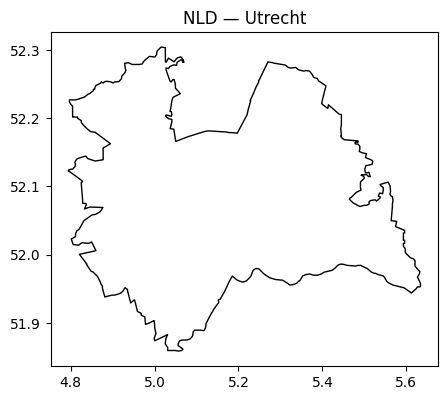

Area ≈ 4118.3 km²


In [4]:
city = find_city_polygon(GADM, ISO3, CITY)
fig, ax = plt.subplots(figsize=(5,5))
city.plot(ax=ax, facecolor="none", edgecolor="k")
ax.set_title(f"{ISO3} — {CITY}")
plt.show()
print(f"Area ≈ {city.to_crs('EPSG:3857').area.iloc[0]/1e6:.1f} km²")

### Urban vs rural ring geometry

/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_5736/170474303.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  ring = gpd.GeoDataFrame(geometry=(city_m.buffer(RING_KM*1000).difference(city_m.unary_union)), crs=city_m.crs)
/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_5736/170474303.py:7: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(); ax.set_title("City vs Rural ring"); plt.show()
/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_5736/170474303.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(); ax.set_title("City vs Rural ring"); plt.show()


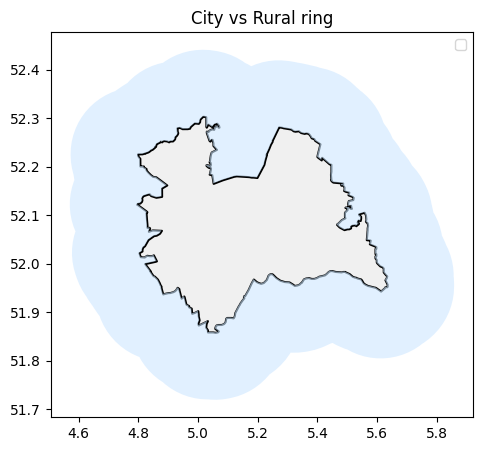

In [5]:
city_m = city.to_crs("EPSG:3857")
ring = gpd.GeoDataFrame(geometry=(city_m.buffer(RING_KM*1000).difference(city_m.unary_union)), crs=city_m.crs)
ring = ring.to_crs("EPSG:4326")
fig, ax = plt.subplots(figsize=(6,5))
city.plot(ax=ax, color="#f0f0f0", edgecolor="k", linewidth=1.5, label="City")
ring.plot(ax=ax, color="#cde7ff", edgecolor="none", alpha=0.6, label=f"Rural ring {RING_KM} km")
ax.legend(); ax.set_title("City vs Rural ring"); plt.show()

### Sentinel-2 NDVI — city and rural ring means


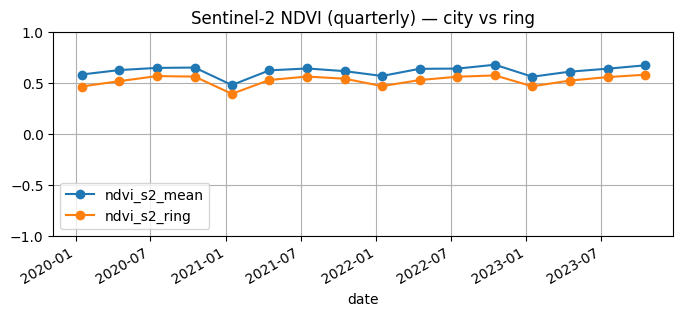

In [6]:
s2_df = pd.DataFrame()
s2_ring_df = pd.DataFrame()
if S2_NDVI.exists():
    qlist = list_s2_quarters(S2_NDVI)
    rows_city, rows_ring = [], []
    for _, r in qlist.iterrows():
        img_c, _ = clip_raster_to_polygon(r["path"], city, crop=True)
        img_r, _ = clip_raster_to_polygon(r["path"], ring, crop=True)
        rows_city.append({"date": r["mid"], "ndvi_s2_mean": float(np.nanmean(img_c[0]))})
        rows_ring.append({"date": r["mid"], "ndvi_s2_ring": float(np.nanmean(img_r[0]))})
        del img_c, img_r; gc.collect()
    if rows_city:
        s2_df = pd.DataFrame(rows_city).set_index("date").sort_index()
        s2_ring_df = pd.DataFrame(rows_ring).set_index("date").sort_index()
        s2_df = s2_df.join(s2_ring_df, how="left")
        s2_df["ndvi_s2_contrast"] = s2_df["ndvi_s2_mean"] - s2_df["ndvi_s2_ring"]
        fig, ax = plt.subplots(figsize=(8,3))
        s2_df[["ndvi_s2_mean","ndvi_s2_ring"]].plot(ax=ax, marker="o")
        ax.set_ylim(-1,1); ax.grid(True); ax.set_title("Sentinel-2 NDVI (quarterly) — city vs ring")
        plt.show()



### ERA5 daily to monthly: city vs rural ring and UHI intensity


/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_5736/3026648906.py:49: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 31. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_5736/3026648906.py:49: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 31. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_5736/3026648906.py:49: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 31. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_5736/3026648906.py:49: UserWarning: The specified chu

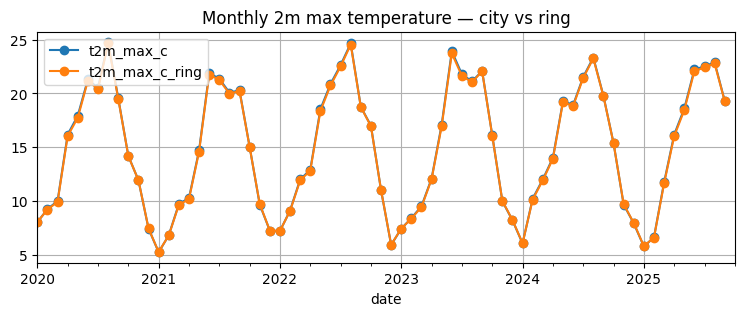

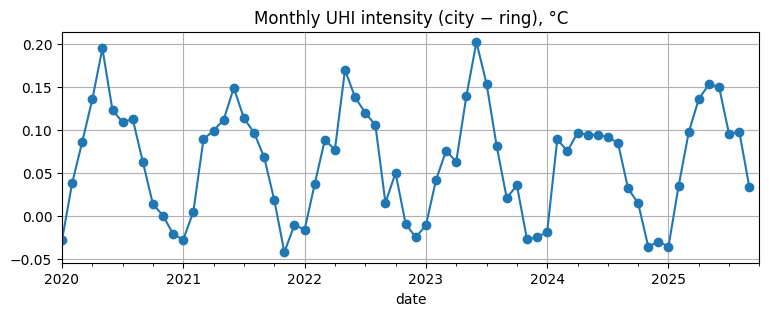

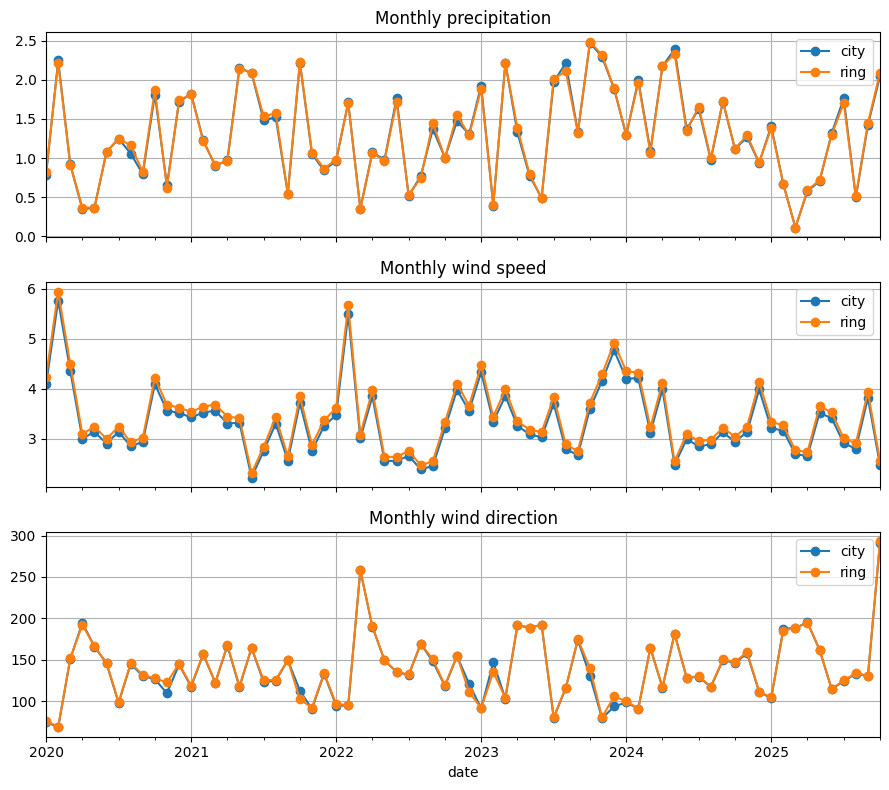

In [7]:
cfg = era5_var_map()
ds_t2m = open_era5(ERA5_YEARS, "2m_temperature", ERA5_DAILY)
t2m = kelvin_to_celsius(ds_t2m[cfg["2m_temperature"][1]])
ds_tp = open_era5(ERA5_YEARS, "total_precipitation", ERA5_DAILY)
tp = m_to_mm(ds_tp[cfg["total_precipitation"][1]])
ds_u = open_era5(ERA5_YEARS, "10m_u_component_of_wind", ERA5_DAILY)
ds_v = open_era5(ERA5_YEARS, "10m_v_component_of_wind", ERA5_DAILY)
u = ds_u[cfg["10m_u_component_of_wind"][1]]
v = ds_v[cfg["10m_v_component_of_wind"][1]]

t2m_city = area_mean_clip_da(t2m, city).rename("t2m_max_c")
t2m_ring = area_mean_clip_da(t2m, ring).rename("t2m_max_c_ring")
tp_city = area_mean_clip_da(tp, city).rename("tp_mm_day")
tp_ring = area_mean_clip_da(tp, ring).rename("tp_mm_day_ring")
spd_city, dir_city = wind_speed_dir(area_mean_clip_da(u, city), area_mean_clip_da(v, city))
spd_city = spd_city.rename("wind_speed_ms"); dir_city = dir_city.rename("wind_dir_deg")
spd_ring, dir_ring = wind_speed_dir(area_mean_clip_da(u, ring), area_mean_clip_da(v, ring))
spd_ring = spd_ring.rename("wind_speed_ms_ring"); dir_ring = dir_ring.rename("wind_dir_deg_ring")

era5_daily = xr.merge([t2m_city, t2m_ring, tp_city, tp_ring, spd_city, spd_ring, dir_city, dir_ring], join="outer", compat="override").to_dataframe()
era5_daily.index.name = "date"

monthly = era5_daily.resample("MS").mean()
monthly["UHI_intensity"] = monthly["t2m_max_c"] - monthly["t2m_max_c_ring"]

fig, ax = plt.subplots(figsize=(9,3))
monthly[["t2m_max_c","t2m_max_c_ring"]].plot(ax=ax, marker="o")
ax.set_title("Monthly 2m max temperature — city vs ring"); ax.grid(True); plt.show()

fig, ax = plt.subplots(figsize=(9,3))
monthly["UHI_intensity"].plot(ax=ax, marker="o")
ax.set_title("Monthly UHI intensity (city − ring), °C"); ax.grid(True); plt.show()

fig, axes = plt.subplots(3,1,figsize=(9,8), sharex=True)
monthly["tp_mm_day"].plot(ax=axes[0], marker="o", label="city"); monthly["tp_mm_day_ring"].plot(ax=axes[0], marker="o", label="ring"); axes[0].legend(); axes[0].set_title("Monthly precipitation")
monthly["wind_speed_ms"].plot(ax=axes[1], marker="o", label="city"); monthly["wind_speed_ms_ring"].plot(ax=axes[1], marker="o", label="ring"); axes[1].legend(); axes[1].set_title("Monthly wind speed")
monthly["wind_dir_deg"].plot(ax=axes[2], marker="o", label="city"); monthly["wind_dir_deg_ring"].plot(ax=axes[2], marker="o", label="ring"); axes[2].legend(); axes[2].set_title("Monthly wind direction")
for a in axes: a.grid(True)
plt.tight_layout(); plt.show()


### Seasonal cycle and distribution of UHI intensity

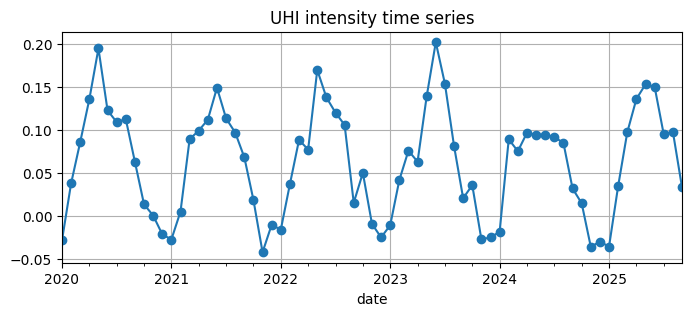

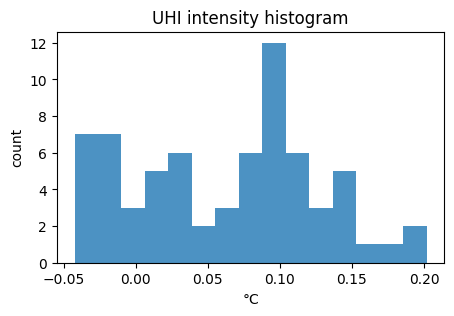

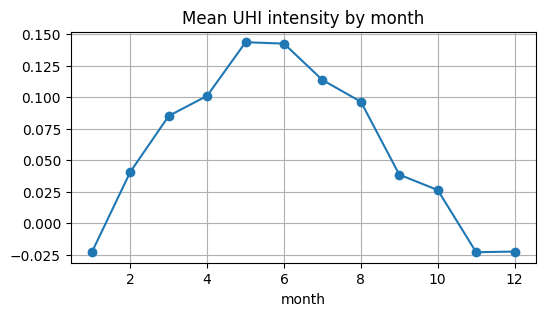

In [8]:
uhi = monthly["UHI_intensity"].dropna()
fig, ax = plt.subplots(figsize=(8,3))
uhi.plot(ax=ax, marker="o"); ax.grid(True); ax.set_title("UHI intensity time series"); plt.show()

fig, ax = plt.subplots(figsize=(5,3))
ax.hist(uhi.values, bins=15, alpha=0.8)
ax.set_title("UHI intensity histogram"); ax.set_xlabel("°C"); ax.set_ylabel("count"); plt.show()

cycle = monthly.groupby(monthly.index.month)["UHI_intensity"].mean()
fig, ax = plt.subplots(figsize=(6,3))
cycle.plot(ax=ax, marker="o")
ax.set_title("Mean UHI intensity by month"); ax.set_xlabel("month"); ax.grid(True); plt.show()


### ERA5 field map for a sample day with city boundary

/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_5736/3026648906.py:49: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 31. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(


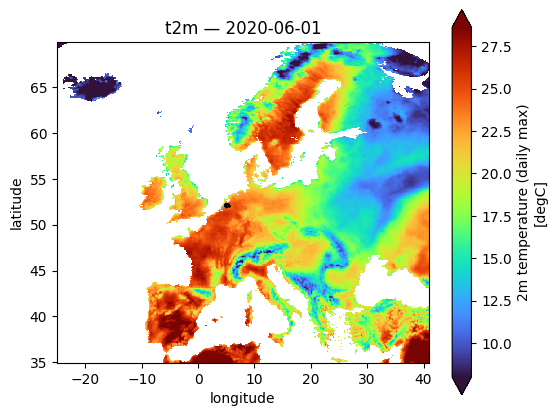

28221

In [9]:
year = 2020
variable = "2m_temperature"
stat, datavar = era5_var_map()[variable]
ds_one = open_era5([year], variable, ERA5_DAILY)
day = pd.to_datetime(f"{year}-06-01")
da = kelvin_to_celsius(ds_one[datavar]).sel(valid_time=day)
if "number" in da.dims:
    da = da.isel(number=0)
fig, ax = plt.subplots(figsize=(6,5))
im = da.plot(ax=ax, cmap="turbo", robust=True)
city.to_crs("EPSG:4326").boundary.plot(ax=ax, color="k", linewidth=1.2)
ax.set_title(f"{datavar} — {str(day.date())}"); ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
plt.show()
del ds_one, da; gc.collect()


/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_5736/3026648906.py:49: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 31. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(


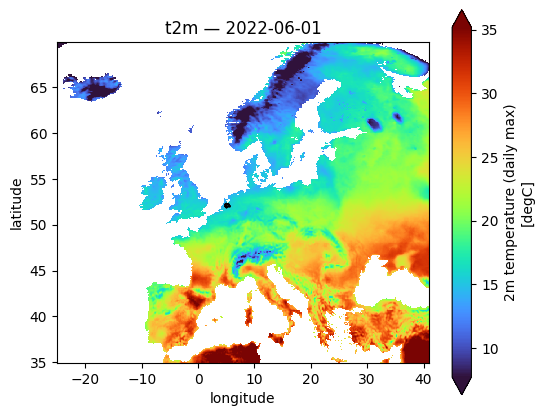

6261

In [10]:
year = 2022
variable = "2m_temperature"
stat, datavar = era5_var_map()[variable]
ds_one = open_era5([year], variable, ERA5_DAILY)
day = pd.to_datetime(f"{year}-06-01")
da = kelvin_to_celsius(ds_one[datavar]).sel(valid_time=day)
if "number" in da.dims:
    da = da.isel(number=0)
fig, ax = plt.subplots(figsize=(6,5))
im = da.plot(ax=ax, cmap="turbo", robust=True)
city.to_crs("EPSG:4326").boundary.plot(ax=ax, color="k", linewidth=1.2)
ax.set_title(f"{datavar} — {str(day.date())}"); ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
plt.show()
del ds_one, da; gc.collect()


/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_5736/3026648906.py:49: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 31. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(


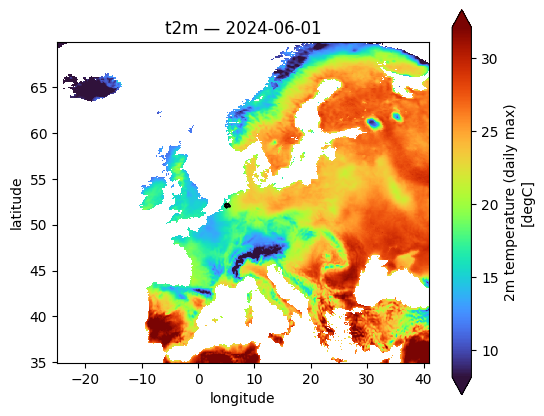

6079

In [11]:
year = 2024
variable = "2m_temperature"
stat, datavar = era5_var_map()[variable]
ds_one = open_era5([year], variable, ERA5_DAILY)
day = pd.to_datetime(f"{year}-06-01")
da = kelvin_to_celsius(ds_one[datavar]).sel(valid_time=day)
if "number" in da.dims:
    da = da.isel(number=0)
fig, ax = plt.subplots(figsize=(6,5))
im = da.plot(ax=ax, cmap="turbo", robust=True)
city.to_crs("EPSG:4326").boundary.plot(ax=ax, color="k", linewidth=1.2)
ax.set_title(f"{datavar} — {str(day.date())}"); ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
plt.show()
del ds_one, da; gc.collect()


### Wind context: polar rose (city)

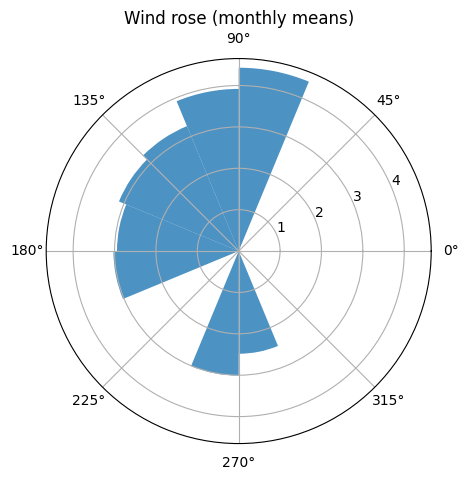

In [12]:
wd = monthly["wind_dir_deg"].dropna().values
ws = monthly["wind_speed_ms"].reindex(monthly["wind_dir_deg"].dropna().index).values
wd_rad = np.deg2rad(wd)
bins = np.linspace(0, 2*np.pi, 17)
idx = np.digitize(wd_rad, bins) - 1
ws_mean = pd.Series(ws).groupby(idx).mean()
theta = 0.5*(bins[:-1] + bins[1:])
r = ws_mean.reindex(range(len(theta))).fillna(0).values
fig = plt.figure(figsize=(5,5))
ax = plt.subplot(111, projection="polar")
ax.bar(theta, r, width=(2*np.pi/16), alpha=0.8)
ax.set_title("Wind rose (monthly means)"); plt.show()


### NDVI–UHI relationships

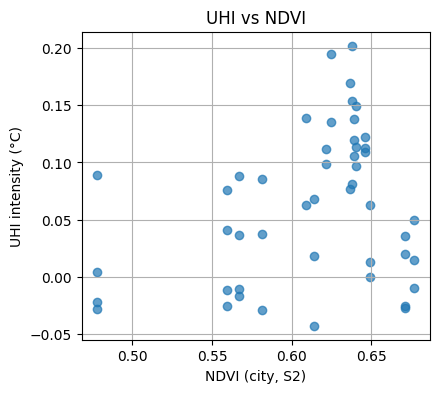

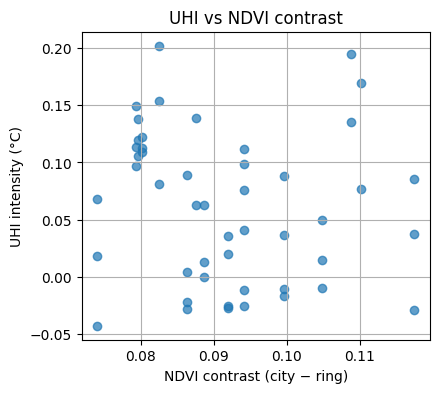

In [13]:
ndvi_month = None
if not s2_df.empty:
    ndvi_month = s2_df["ndvi_s2_mean"].reindex(monthly.index, method="nearest", tolerance=pd.Timedelta(days=S2_TO_MONTH_TOLERANCE_DAYS))
    ndvi_contrast = s2_df["ndvi_s2_contrast"].reindex(monthly.index, method="nearest", tolerance=pd.Timedelta(days=S2_TO_MONTH_TOLERANCE_DAYS))
    fig, ax = plt.subplots(figsize=(4.5,4))
    ax.scatter(ndvi_month, monthly["UHI_intensity"], alpha=0.7)
    ax.set_xlabel("NDVI (city, S2)"); ax.set_ylabel("UHI intensity (°C)"); ax.set_title("UHI vs NDVI"); ax.grid(True); plt.show()
    fig, ax = plt.subplots(figsize=(4.5,4))
    ax.scatter(ndvi_contrast, monthly["UHI_intensity"], alpha=0.7)
    ax.set_xlabel("NDVI contrast (city − ring)"); ax.set_ylabel("UHI intensity (°C)"); ax.set_title("UHI vs NDVI contrast"); ax.grid(True); plt.show()



### Stations: in-city subset and K-nearest around centroid

/var/folders/r9/90gtpm7d3jb6fmfnfx4j1r_r0000gn/T/ipykernel_5736/2869470863.py:8: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  stations_in_city = stations_gdf[stations_gdf.within(city_ll.unary_union)]


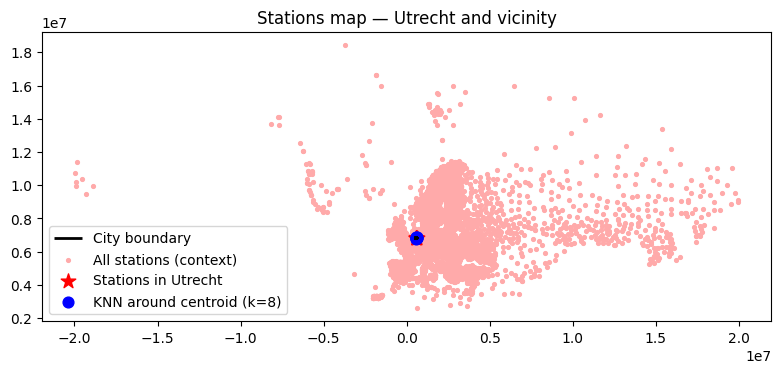

In-city stations: 4 — example: STAID 162 DE BILT (NL)


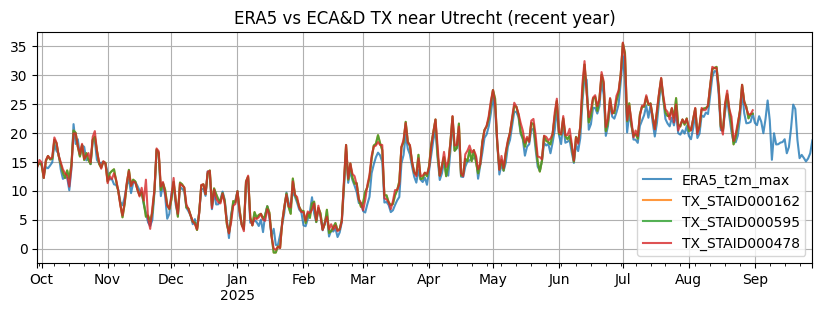

Daily correlation matrix (recent overlap):


,ERA5_t2m_max,TX_STAID000162,TX_STAID000595,TX_STAID000478
ERA5_t2m_max,1.000000,0.992495,0.992495,0.992370
TX_STAID000162,0.992495,1.000000,0.998769,0.996564
TX_STAID000595,0.992495,0.998769,1.000000,0.996188
TX_STAID000478,0.992370,0.996564,0.996188,1.000000


In [14]:
stations_file = ECA_TX / "stations.txt"
stations_gdf = None
stations_in_city = None
selected_knn = None
if stations_file.exists():
    stations_gdf = parse_ecad_stations(stations_file)
    city_ll = city.to_crs(stations_gdf.crs)
    stations_in_city = stations_gdf[stations_gdf.within(city_ll.unary_union)]
    centroid = city_ll.geometry.iloc[0].centroid
    pts = np.column_stack([stations_gdf.geometry.x.values, stations_gdf.geometry.y.values])
    cxy = np.array([centroid.x, centroid.y])
    d = np.sqrt(((pts - cxy)**2).sum(axis=1))
    k = 8
    sel_idx = np.argsort(d)[:k]
    selected_knn = stations_gdf.iloc[sel_idx]
    base = city_ll.to_crs("EPSG:3857"); st_all = stations_gdf.to_crs("EPSG:3857"); st_in = stations_in_city.to_crs("EPSG:3857"); st_knn = selected_knn.to_crs("EPSG:3857")
    fig, ax = plt.subplots(figsize=(8,7))
    base.plot(ax=ax, alpha=0.25, color="lightgray"); base.boundary.plot(ax=ax, color="k", linewidth=2, label="City boundary")
    st_all.plot(ax=ax, color="#ffaaaa", markersize=30, marker=".", label="All stations (context)")
    st_in.plot(ax=ax, color="red", markersize=120, marker="*", label=f"Stations in {CITY}")
    st_knn.plot(ax=ax, color="blue", markersize=60, marker="o", label=f"KNN around centroid (k={k})")
    ax.legend(); ax.set_title(f"Stations map — {CITY} and vicinity"); plt.tight_layout(); plt.show()
    if len(stations_in_city):
        row = stations_in_city.iloc[0]
        print(f"In-city stations: {len(stations_in_city)} — example: STAID {int(row['STAID'])} {row['STANAME']} ({row['CN']})")
    else:
        print("No stations strictly inside the city polygon.")
else:
    print("stations.txt not found")

# %% [markdown]
# ## Optional: read TX for up to 3 nearest stations and compare with ERA5 city daily

# %%
tx_df = pd.DataFrame()
if selected_knn is not None and len(selected_knn):
    wanted_ids = [int(x) for x in selected_knn["STAID"].dropna().astype(int).tolist()]
    candidates = []
    for stid in wanted_ids[:5]:
        for pad in (5,6):
            cand = ECA_TX / f"TX_STAID{stid:0{pad}d}.txt"
            if cand.exists():
                candidates.append(cand); break
    if not candidates:
        candidates = sorted(ECA_TX.glob("TX_STAID*.txt"))[:3]
    tx_series = []
    for p in candidates[:3]:
        try:
            s = read_one_tx_file(p)
            tx_series.append(s.rename(p.stem))
        except Exception as e:
            pass
    if tx_series:
        tx_df = pd.concat(tx_series, axis=1).resample("D").mean()
        daily_city_t2m = era5_daily["t2m_max_c"].copy()
        daily_city_t2m.index = pd.DatetimeIndex(daily_city_t2m.index)
        both = pd.concat([daily_city_t2m.rename("ERA5_t2m_max"), tx_df], axis=1).dropna(how="all")
        fig, ax = plt.subplots(figsize=(10,3))
        both.tail(365).plot(ax=ax, alpha=0.8)
        ax.set_title(f"ERA5 vs ECA&D TX near {CITY} (recent year)"); ax.grid(True); plt.show()
        cmat = both.corr(numeric_only=True)
        print("Daily correlation matrix (recent overlap):")
        display(cmat)

### UVHS proxy (communication metric)

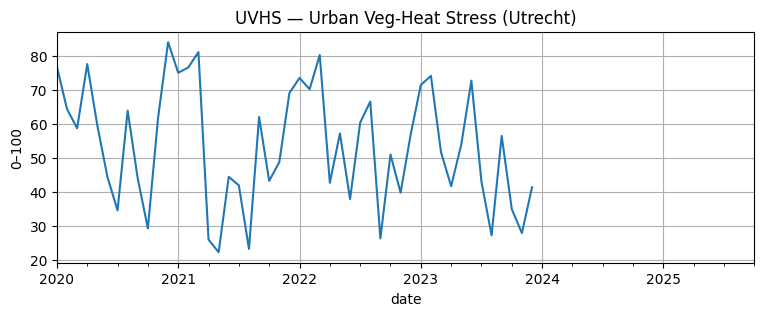

In [15]:
feat = monthly.copy()
ndvi_used = None
if ndvi_month is not None:
    ndvi_used = ndvi_month.copy()
elif not s2_df.empty:
    ndvi_used = s2_df["ndvi_s2_mean"].reindex(monthly.index, method="nearest", tolerance=pd.Timedelta(days=S2_TO_MONTH_TOLERANCE_DAYS))
else:
    ndvi_used = pd.Series(index=monthly.index, dtype=float)
clim = feat.groupby(feat.index.month)[["t2m_max_c"]].mean().rename_axis("month")
anom = feat["t2m_max_c"].copy()
for idx, val in feat["t2m_max_c"].items():
    anom.loc[idx] = val - clim.loc[idx.month, "t2m_max_c"]
feat["heat_z"] = robust_z(anom)
feat["dry_z"] = robust_z(-feat["tp_mm_day"])
greenness_0_1 = (ndvi_used.clip(-1,1) + 1.0) / 2.0
feat["low_ndvi_z"] = robust_z(1.0 - greenness_0_1)
w_heat, w_ndvi, w_dry = 0.45, 0.35, 0.20
raw = (w_heat*feat["heat_z"] + w_ndvi*feat["low_ndvi_z"] + w_dry*feat["dry_z"])
feat["UVHS_score"] = (100.0/(1.0+np.exp(-raw))).clip(0,100)
fig, ax = plt.subplots(figsize=(9,3))
feat["UVHS_score"].plot(ax=ax)
ax.set_ylabel("0–100"); ax.set_title(f"UVHS — Urban Veg-Heat Stress ({CITY})"); ax.grid(True); plt.show()



### NDVI spatial snapshot and quartiles (city)


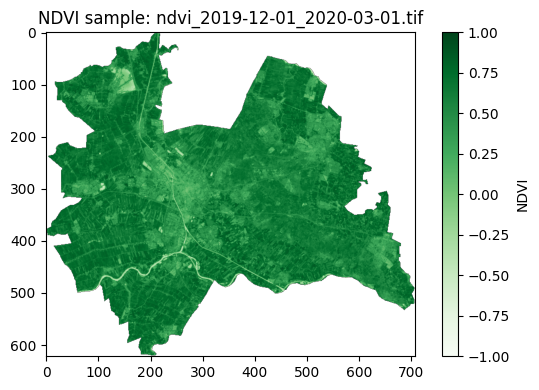

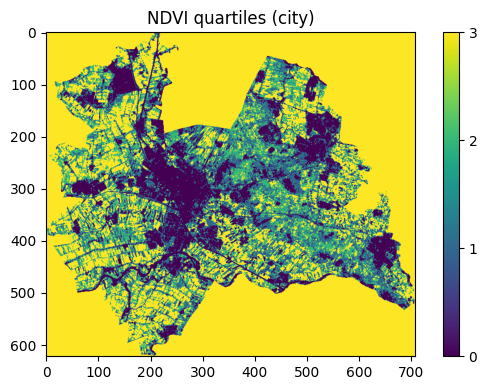

In [16]:
s2_any = sorted(S2_NDVI.glob("ndvi_*.tif"))
if s2_any:
    sample = s2_any[0]
    arr, meta = clip_raster_to_polygon(sample, city, crop=True)
    z = arr[0]
    fig, ax = plt.subplots(figsize=(6,4))
    im = ax.imshow(z, vmin=-1, vmax=1, cmap="Greens")
    ax.set_title(f"NDVI sample: {sample.name}"); plt.colorbar(im, ax=ax, label="NDVI"); plt.tight_layout(); plt.show()
    qs = np.nanpercentile(z, [25,50,75])
    classes = np.digitize(z, qs)
    fig, ax = plt.subplots(figsize=(6,4))
    im = ax.imshow(classes, vmin=0, vmax=3)
    ax.set_title("NDVI quartiles (city)"); plt.colorbar(im, ax=ax, ticks=[0,1,2,3]); plt.tight_layout(); plt.show()



### Bivariate communication panels


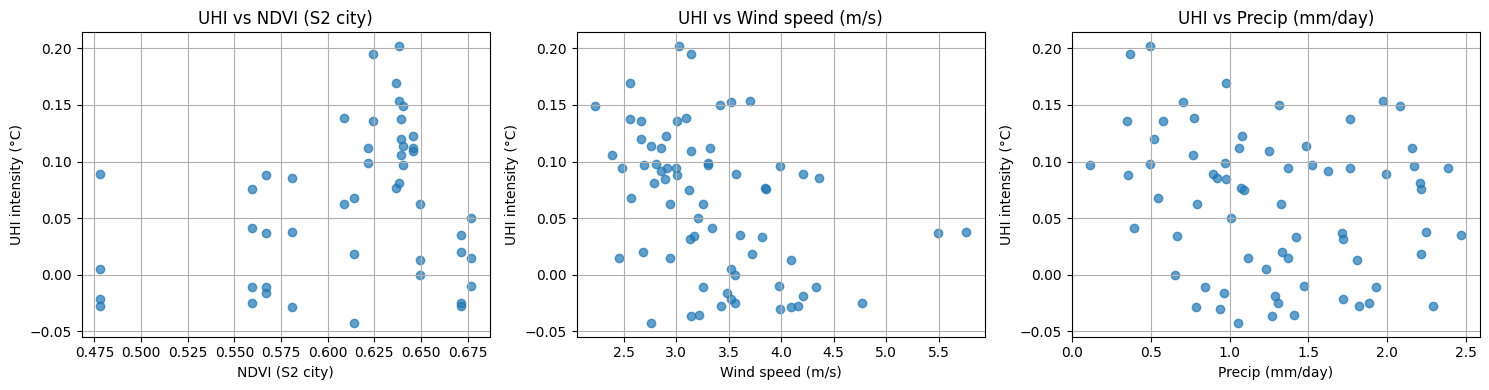

In [17]:
pairs = []
if ndvi_month is not None:
    pairs.append(("NDVI (S2 city)", ndvi_month))
pairs.append(("Wind speed (m/s)", monthly["wind_speed_ms"]))
pairs.append(("Precip (mm/day)", monthly["tp_mm_day"]))
fig, axes = plt.subplots(1, len(pairs), figsize=(5*len(pairs),4))
axes = np.atleast_1d(axes)
for ax, (lbl, series) in zip(axes, pairs):
    common = pd.concat([monthly["UHI_intensity"], series], axis=1).dropna()
    ax.scatter(common.iloc[:,1], common.iloc[:,0], alpha=0.7)
    ax.set_xlabel(lbl); ax.set_ylabel("UHI intensity (°C)"); ax.grid(True)
    ax.set_title(f"UHI vs {lbl}")
plt.tight_layout(); plt.show()



### Export monthly features

In [ ]:
export = monthly.copy()
export["country"] = ISO3
export["city"] = CITY
if ndvi_month is not None:
    export["ndvi_s2_mean"] = ndvi_month
if not s2_df.empty and "ndvi_s2_mean" not in export:
    export["ndvi_s2_mean"] = s2_df["ndvi_s2_mean"].reindex(export.index, method="nearest", tolerance=pd.Timedelta(days=S2_TO_MONTH_TOLERANCE_DAYS))
export["UVHS_score"] = feat["UVHS_score"]
export = export[[
    "country","city","t2m_max_c","t2m_max_c_ring","UHI_intensity",
    "tp_mm_day","tp_mm_day_ring","wind_speed_ms","wind_speed_ms_ring",
    "wind_dir_deg","wind_dir_deg_ring","ndvi_s2_mean","UVHS_score"
]]
csv_path = OUT / f"period2_features_{ISO3}_{CITY}.csv"
export.to_csv(csv_path, index=True)
print(csv_path.resolve())